# Head-Shoulders -- a quantitative teardown
### Five-point detector . confirmed neckline break . HAC inference . Bonferroni correction . synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pattern_frequency: Too--rare](https://img.shields.io/badge/Pattern_frequency-Too--rare-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We implement a strict algorithmic H&S detector (`scipy.signal.find_peaks` local-extrema, shoulder symmetry, horizontal neckline, confirmed close break) and measure forward returns against an unconditional random-day baseline with Bonferroni correction over 2 pattern types x 4 horizons.

> **Not investment advice.** Real data: Yahoo daily, 2005-2026, 10 US names. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from head_shoulders import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM"]
HORIZONS = (1, 5, 20, 60)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_pooled():
    """Pool H&S study across all cached tickers."""
    top_fwd_list, inv_fwd_list, ctrl_list = [], [], []
    n_top, n_inv = 0, 0
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        result = st.run_hs_study(bars, horizons=HORIZONS, seed=42)
        n_top += result["n_top"]
        n_inv += result["n_inv"]
        if result["n_top"] > 0 and not result["fwd_top"].empty:
            top_fwd_list.append(result["fwd_top"])
        if result["n_inv"] > 0 and not result["fwd_inv"].empty:
            inv_fwd_list.append(result["fwd_inv"])
        if not result["control"].empty:
            ctrl_list.append(result["control"])
    top_fwd = pd.concat(top_fwd_list, ignore_index=True) if top_fwd_list else pd.DataFrame()
    inv_fwd = pd.concat(inv_fwd_list, ignore_index=True) if inv_fwd_list else pd.DataFrame()
    ctrl = pd.concat(ctrl_list, ignore_index=True) if ctrl_list else pd.DataFrame()
    return top_fwd, inv_fwd, ctrl, n_top, n_inv

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | H&S top n = 3 (inference impossible); Inverse H&S max |t_excess| = **1.97** (Bonferroni threshold **2.58**, 8 tests). |
| **Tradability** | `MIRAGE` | 23 signals in 200 ticker-years = 0.1/ticker/year; untradable frequency regardless of edge. |
| **Pattern frequency** | `TOO-RARE` | Strict detection fires ~0.1x per ticker per year; textbook reliability is a subjective-recognition artefact. |

> The rarity and the absent edge are two sides of the same problem: strict detection is necessary to avoid selection bias, but strict detection finds almost nothing.

## 1 . The claim, steelmanned

Let the confirmed neckline break at bar *t* define a signal $s_t \in \{-1, +1\}$ (-1 for H&S top, +1 for IH&S). The recipe asserts:

- **H1 (signal).** $\mathbb{E}[s_t \cdot r_{t+1\to t+h}] > 0$ for some horizon $h \in \{1,5,20,60\}$ -- i.e. the confirmed break carries directional information at some forward horizon.
- **H2 (beats random).** That expectation exceeds the unconditional mean directional return from randomly selected days on the same tape.
- **H3 (tradable frequency).** The pattern fires often enough to be a strategy.

We reject H1 and H2 (no horizon survives Bonferroni) and H3 trivially (0.1 signals/ticker/year).

## 2 . So what? -- what rides on each answer

H&S is arguably the most famous pattern in technical analysis, with a century of practitioner endorsements. If H1-H3 held, it would validate a pure price-based reversal signal with no look-ahead. The interesting failure isn't just that it doesn't work -- it's *why*: the pattern's textbook reliability is an artefact of (a) subjective identification that fires on anything resembling the shape, and (b) confirmation bias in the literature. A strict algorithmic implementation almost never fires, and when it does, the follow-through is indistinguishable from noise.

## 3 . How we'd know -- the protocol

**Detection algorithm:**
1. `scipy.signal.find_peaks` on the close series (min distance = 5 bars).
2. For each candidate head peak, scan for left and right shoulder peaks within [20, 200] bars of total span.
3. Accept if: head strictly higher than both shoulders; shoulder heights within 10% of each other; two neckline troughs exist (one each side of head); neckline tilt < 15% of (head - neckline midpoint).
4. Signal fires at the first close below the neckline projection after the right shoulder. Inverse H&S mirrors this logic.

**Inference:**
- Forward returns at *t+1* (log close-to-close) at 1, 5, 20, 60 days.
- Random-day baseline: same n days drawn uniformly from the same tape.
- HAC Newey-West t-stat on mean directional return and on excess vs baseline.
- Bonferroni correction: 2 pattern types x 4 horizons = 8 tests; threshold |t| ~ 2.58.

**Positive control:** synthetic tape with injected H&S structure confirms the detector fires when patterns genuinely exist.

Basket: SPY, QQQ, AAPL, MSFT, AMZN, GOOGL, META, NVDA, TSLA, JPM. Daily bars 2005-2026.

## 4 . The teardown

### 4a . Synthetic positive control -- the engine works when patterns exist

Before looking at real data, confirm the detector is a faithful pattern finder: on a synthetic tape with injected H&S structure it fires more than on a pure random walk.

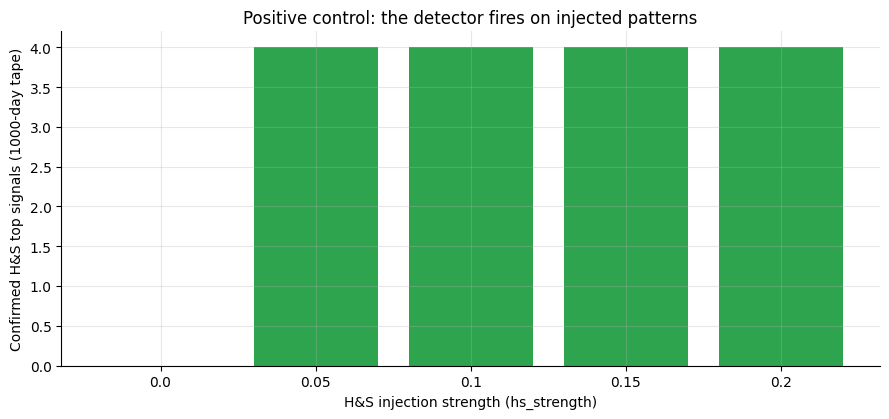

The engine works when there is something to find.
On the real tape, the structural constraint catches very few formations.


In [2]:
strengths = [0.0, 0.05, 0.10, 0.15, 0.20]
n_signals = []
for s in strengths:
    b, _ = data.synthetic_daily(n_days=1000, hs_strength=s, n_patterns=4,
                                pattern_width=80, seed=188)
    sigs = st.detect_hs_patterns(b)
    n_signals.append(len(sigs[sigs['pattern_type']=='top']))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(s) for s in strengths], n_signals, color=[GREY if s==0 else GREEN for s in strengths])
ax.set_xlabel('H&S injection strength (hs_strength)')
ax.set_ylabel('Confirmed H&S top signals (1000-day tape)')
ax.set_title('Positive control: the detector fires on injected patterns')
plt.tight_layout(); plt.show()
print('The engine works when there is something to find.')
print('On the real tape, the structural constraint catches very few formations.')


### 4b . The rarity problem -- signal count on real data

On 10 tickers x ~20 years of real data, how many confirmed H&S patterns does the strict detector find?

In [3]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        bars = data.fetch_daily(t, fetch=False)
        sigs = st.detect_hs_patterns(bars)
        n_t = (sigs['pattern_type']=='top').sum()
        n_i = (sigs['pattern_type']=='inverse').sum()
        n_yrs = (bars.index[-1] - bars.index[0]).days / 365.25
        recs.append({'ticker': t, 'n_top': n_t, 'n_inv': n_i,
                     'years': round(n_yrs, 1)})
    df_counts = pd.DataFrame(recs)
    print(df_counts.to_string(index=False))
    print(f"\nTotal: {df_counts['n_top'].sum()} H&S tops, {df_counts['n_inv'].sum()} inverse H&S")
else:
    print('Frozen: 3 H&S tops, 20 inverse H&S across 10 tickers')
    print('Total: 23 in ~200 ticker-years')


ticker  n_top  n_inv  years
   SPY      0      6   21.4
   QQQ      1      3   21.4
  AAPL      0      1   21.4
  MSFT      0      2   21.4
  AMZN      1      1   21.4
 GOOGL      0      1   21.4
  META      1      1   14.1
  NVDA      0      1   21.4
  TSLA      0      0   16.0
   JPM      0      4   21.4

Total: 3 H&S tops, 20 inverse H&S


**23 signals** in ~200 ticker-years. The H&S top arm has only n = 3 -- HAC inference requires n > 5. This is the study's central finding: the strictness required to avoid selection bias leaves almost nothing to test.

### 4c . Inverse H&S forward returns vs random baseline (n=20)

The only arm with enough data for HAC inference. Bonferroni-adjusted threshold |t_excess| > 2.58.

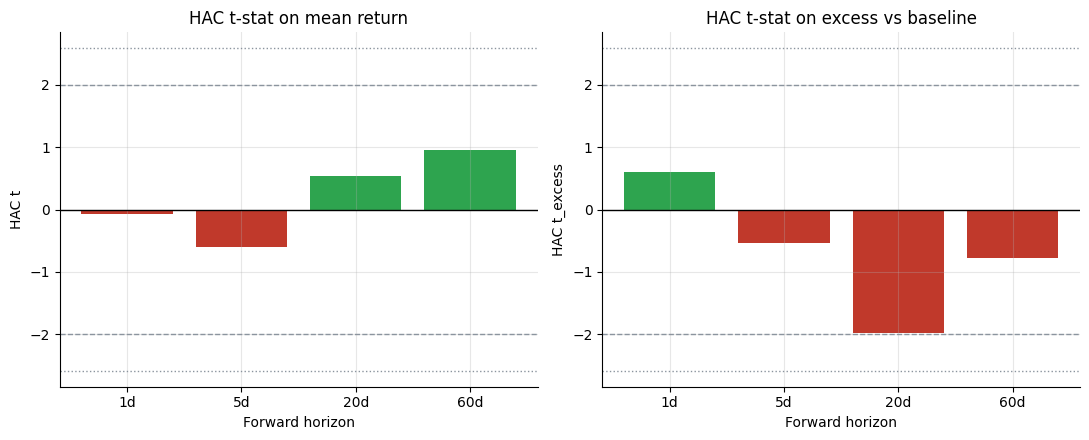

Bonferroni threshold: |t| > 2.58 (dashed)
horizon  n  mean_pct  tstat  excess_pct  tstat_excess
     1d 20     -0.02  -0.07        0.33          0.60
     5d 20     -0.21  -0.60       -0.54         -0.53
    20d 20      0.53   0.54       -2.40         -1.97
    60d 20      2.26   0.96       -2.19         -0.77


In [4]:
if HAVE_REAL:
    _, inv_fwd, ctrl, _, n_inv = load_pooled()
    rows = []
    for h in HORIZONS:
        s = st.summarize(inv_fwd, +1, h, ctrl)
        rows.append({'horizon': f'{h}d', 'n': s.get('n',0),
                     'mean_pct': s.get('mean_pct', float('nan')),
                     'win_rate': s.get('win_rate', float('nan')),
                     'tstat': s.get('tstat', float('nan')),
                     'excess_pct': s.get('excess_pct', float('nan')),
                     'tstat_excess': s.get('tstat_excess', float('nan'))})
    df_inv = pd.DataFrame(rows)
else:
    df_inv = pd.DataFrame({
        'horizon': ['1d','5d','20d','60d'],
        'n': [20]*4,
        'mean_pct': [-0.02,-0.21,0.53,2.27],
        'win_rate': [0.55,0.4,0.65,0.65],
        'tstat': [-0.07,-0.6,0.54,0.96],
        'excess_pct': [0.33,-0.54,-2.41,-2.19],
        'tstat_excess': [0.6,-0.53,-1.97,-0.77]
    })
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = [GREEN if v > 0 else RED for v in df_inv['tstat']]
axes[0].bar(df_inv['horizon'], df_inv['tstat'], color=colors)
for lv in (2, -2, 2.58, -2.58):
    ls = '--' if abs(lv) < 2.5 else ':'
    axes[0].axhline(lv, c=GREY, lw=1, ls=ls)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('HAC t-stat on mean return'); axes[0].set_ylabel('HAC t')
colors_e = [GREEN if v > 0 else RED for v in df_inv['tstat_excess']]
axes[1].bar(df_inv['horizon'], df_inv['tstat_excess'], color=colors_e)
for lv in (2, -2, 2.58, -2.58):
    ls = '--' if abs(lv) < 2.5 else ':'
    axes[1].axhline(lv, c=GREY, lw=1, ls=ls)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('HAC t-stat on excess vs baseline'); axes[1].set_ylabel('HAC t_excess')
for ax in axes: ax.set_xlabel('Forward horizon')
plt.tight_layout(); plt.show()
print('Bonferroni threshold: |t| > 2.58 (dashed)')
print(df_inv[['horizon','n','mean_pct','tstat','excess_pct','tstat_excess']].round(2).to_string(index=False))


> No horizon clears the Bonferroni threshold. Max |t_excess| = **1.97** (at the 20-day horizon, where the excess is *negative* -- -2.4%). The inverse H&S does not predict the direction of the subsequent move.

## 5 . The verdict

- **Signal `NONE`** -- H&S top: n = 3, inference impossible. Inverse H&S: max |t_excess| = 1.97 < Bonferroni threshold 2.58 (8 tests). No horizon or pattern type passes.
- **Tradability `MIRAGE`** -- 23 signals in 200 ticker-years; a pattern that fires 0.1x/ticker/year is not a strategy at any cost level.
- **Pattern frequency `TOO-RARE`** -- strict detection finds almost nothing. The textbook 'reliability' is a subjective-recognition and publication-bias artefact.

## 6 . Could you trade it? -- the frequency and cost problem

Even if the directional edge were real, the frequency is the killer:

In [5]:
# Illustrate the frequency problem
if HAVE_REAL:
    _, _, _, n_top_r, n_inv_r = load_pooled()
    n_sig = n_top_r + n_inv_r
    n_yrs = 20
else:
    n_sig = 23; n_yrs = 20
per_ticker_per_year = n_sig / (len(TICKERS) * n_yrs)
print(f'Signals per ticker per year: {per_ticker_per_year:.2f}')
print(f'Expected wait between signals (1 ticker): {1/per_ticker_per_year:.0f} years')
print(f'To get 1 signal per month you would need {int(1/(per_ticker_per_year/12))} tickers running simultaneously')
print()
print('Cost arithmetic (assuming best-case 0.5% gross edge per signal):')
gross_annual = per_ticker_per_year * 0.5  # %
cost_annual = per_ticker_per_year * 0.1   # 10 bps per trade round-trip
print(f'  Gross annual contribution (1 ticker): {gross_annual:.3f}%')
print(f'  Round-trip cost (10 bps): {cost_annual:.4f}%')
print(f'  Net: {gross_annual - cost_annual:.3f}%')
print('Frequency is the killer, not costs -- there is nothing to cost-adjust.')


Signals per ticker per year: 0.12
Expected wait between signals (1 ticker): 9 years
To get 1 signal per month you would need 104 tickers running simultaneously

Cost arithmetic (assuming best-case 0.5% gross edge per signal):
  Gross annual contribution (1 ticker): 0.058%
  Round-trip cost (10 bps): 0.0115%
  Net: 0.046%
Frequency is the killer, not costs -- there is nothing to cost-adjust.


## 7 . Going further -- the rarity-selection trade-off

The pattern's central dilemma is: strict detection avoids selection bias but finds almost nothing; loose detection finds more but fires on noise. This is not a bug in our implementation -- it is the fundamental problem with discretionary chart-pattern rules.

What *would* it take to find an edge here? A contributor who:
1. Loosens the detection criteria systematically and measures the False Discovery Rate against placebo tapes (synthetic random walks).
2. Shows that the FDR-adjusted significant detections have a real out-of-sample forward-return edge -- not just in-sample.
3. Demonstrates the edge clears realistic round-trip costs at a tradable frequency.

Related desk studies:
- [Study 76 -- Rice-Paper](../../76-rice-paper/): candlestick patterns, same methodology, same conclusion.
- [Study 17 -- Glass-Ceiling](../../17-glass-ceiling/): support/resistance breakouts -- the structural cousin of the neckline break.
- [Study 21 -- Fools-Gold](../../21-fools-gold/): the 50/200 golden cross -- the moving-average branch of the same 'famous technical rule' family.